In [1]:
import IJulia
import Base64

# The julia kernel has built in support for Revise.jl, so this is the 
# recommended approach for long-running sessions:
# https://github.com/JuliaLang/IJulia.jl/blob/9b10fa9b879574bbf720f5285029e07758e50a5e/src/kernel.jl#L46-L51

# Users should enable revise within .julia/config/startup_ijulia.jl:
# https://timholy.github.io/Revise.jl/stable/config/#Using-Revise-automatically-within-Jupyter/IJulia-1

# clear console history
IJulia.clear_history()

fig_width = 5
fig_height = 4
fig_format = :png
fig_dpi = 96

# no retina format type, use svg for high quality type/marks
if fig_format == :retina
  fig_format = :svg
elseif fig_format == :pdf
  fig_dpi = 96
  # Enable PDF support for IJulia
  IJulia.register_mime(MIME("application/pdf"))
end

# convert inches to pixels
fig_width = fig_width * fig_dpi
fig_height = fig_height * fig_dpi

# Intialize Plots w/ default fig width/height
try
  import Plots

  # Plots.jl doesn't support PDF output for versions < 1.28.1
  # so use png (if the DPI remains the default of 300 then set to 96)
  if (Plots._current_plots_version < v"1.28.1") & (fig_format == :pdf)
    Plots.gr(size=(fig_width, fig_height), fmt = :png, dpi = fig_dpi)
  else
    Plots.gr(size=(fig_width, fig_height), fmt = fig_format, dpi = fig_dpi)
  end
catch e
  # @warn "Plots init" exception=(e, catch_backtrace())
end

# Initialize CairoMakie with default fig width/height
try
  import CairoMakie

  # CairoMakie's display() in PDF format opens an interactive window
  # instead of saving to the ipynb file, so we don't do that.
  # https://github.com/quarto-dev/quarto-cli/issues/7548
  if fig_format == :pdf
    CairoMakie.activate!(type = "png")
  else
    CairoMakie.activate!(type = string(fig_format))
  end
  CairoMakie.update_theme!(resolution=(fig_width, fig_height))
catch e
    # @warn "CairoMakie init" exception=(e, catch_backtrace())
end
  
# Set run_path if specified
try
  run_path = "L3J1bi9tZWRpYS9hbGYvZGF0b3MvbWlzcmVwb3NpdG9yaW9zL2RvY2VuY2lhL2VjdWFjaW9uZXMtZGlmZXJlbmNpYWxlcy1wcmFjdGljYXMtanVsaWE="
  if !isempty(run_path)
    run_path = String(Base64.base64decode(run_path))
    cd(run_path)
  end
catch e
  @warn "Run path init:" exception=(e, catch_backtrace())
end


# emulate old Pkg.installed beahvior, see
# https://discourse.julialang.org/t/how-to-use-pkg-dependencies-instead-of-pkg-installed/36416/9
import Pkg
function isinstalled(pkg::String)
  any(x -> x.name == pkg && x.is_direct_dep, values(Pkg.dependencies()))
end

# ojs_define
if isinstalled("JSON") && isinstalled("DataFrames")
  import JSON, DataFrames
  global function ojs_define(; kwargs...)
    convert(x) = x
    convert(x::DataFrames.AbstractDataFrame) = Tables.rows(x)
    content = Dict("contents" => [Dict("name" => k, "value" => convert(v)) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
elseif isinstalled("JSON")
  import JSON
  global function ojs_define(; kwargs...)
    content = Dict("contents" => [Dict("name" => k, "value" => v) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
else
  global function ojs_define(; kwargs...)
    @warn "JSON package not available. Please install the JSON.jl package to use ojs_define."
  end
end


# don't return kernel dependencies (b/c Revise should take care of dependencies)
nothing


In [2]:
#| echo: false
#| include: false
packages = ["SymPyPythonCall", "Plots", "LaTeXStrings", "DifferentialEquations", "SpecialFunctions"]

5-element Vector{String}:
 "SymPyPythonCall"
 "Plots"
 "LaTeXStrings"
 "DifferentialEquations"
 "SpecialFunctions"

In [3]:
#| echo: false
#| include: false
using Plots
# Plots y Makie generan además una representación text/html con la imagen en base64
# en una sola línea; con figuras grandes esa línea desborda la pila del conversor
# de Quarto a Markdown. La desactivamos y dejamos solo image/png.
Base.showable(::MIME"text/html", ::Plots.Plot) = false

In [4]:
#| echo: false
using Markdown
v = string(VERSION)
Markdown.parse("![](https://img.shields.io/badge/Julia-$(v)-9558B2?logo=julia)")

![](https://img.shields.io/badge/Julia-1.12.6-9558B2?logo=julia)


In [5]:
#| echo: false
using Markdown
v = string(VERSION)
Markdown.parse("**Versión de Julia:** $(v)")

**Versión de Julia:** 1.12.6


In [6]:
#| echo: false
#| include: false
import Pkg
active_project = Base.active_project()
global_env = joinpath(homedir(), ".julia", "environments", "v$(VERSION.major).$(VERSION.minor)", "Project.toml")
Pkg.activate(global_env)

  Activating project at `~/.julia/environments/v1.12`


In [7]:
#| echo: false
Pkg.status(packages)

Status `~/.julia/environments/v1.12/Project.toml`
  [0c46a032] DifferentialEquations v8.0.2
  [b964fa9f] LaTeXStrings v1.4.0
  [91a5bcdd] Plots v1.41.6
  [276daf66] SpecialFunctions v2.8.0
  [bc8888f7] SymPyPythonCall v0.5.1


In [8]:
#| echo: false
#| include: false
#Pkg.activate(active_project)

In [9]:
using SymPyPythonCall
@syms x t
α = Sym(1)/100
u = 100 * sin(PI * x) * exp(-α * PI^2 * t)
simplify(diff(u, t) - α * diff(u, x, 2))

0

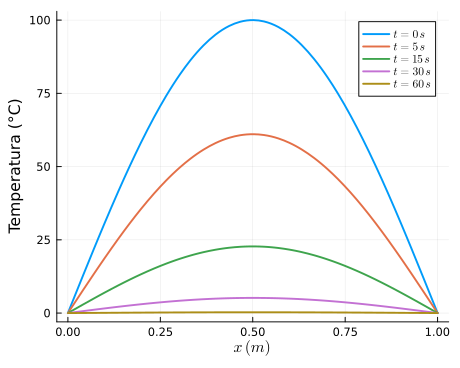

In [10]:
using Plots, LaTeXStrings
usol(x, t) = 100 * sin(π * x) * exp(-0.01 * π^2 * t)
plt = plot(xlab = L"x \; (m)", ylab = "Temperatura (°C)")
for τ in (0, 5, 15, 30, 60)
    plot!(plt, x -> usol(x, τ), 0, 1, lw = 2, label = L"t=%$τ \, s")
end
plt

In [11]:
using SymPyPythonCall
@syms x n::(positive, integer)
b(n) = 2 * (integrate(2x * sin(n*PI*x), (x, 0, Sym(1)/2)) +
            integrate(2*(1-x) * sin(n*PI*x), (x, Sym(1)/2, 1)))
bn = simplify(b(n))

     ⎛π⋅n⎞
8⋅sin⎜───⎟
     ⎝ 2 ⎠
──────────
   2  2   
  π ⋅n    

In [12]:
[simplify(b(k)) for k in 1:5]

5-element Vector{Sym{PythonCall.Py}}:
      8/pi^2
           0
 -8/(9*pi^2)
           0
 8/(25*pi^2)

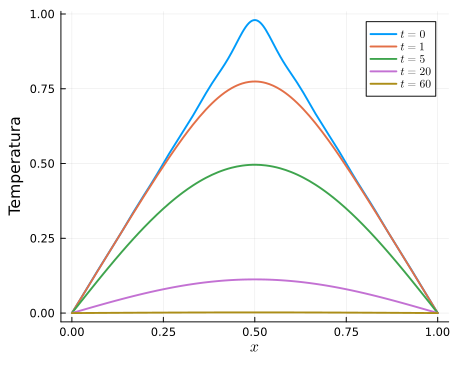

In [13]:
using Plots, LaTeXStrings
bnf(k) = 8 * sin(k*π/2) / (k^2 * π^2)
usol(x, t; N = 20) = sum(bnf(k) * sin(k*π*x) * exp(-0.01*(k*π)^2*t) for k in 1:2:N)
plt = plot(xlab = L"x", ylab = "Temperatura")
for τ in (0, 1, 5, 20, 60)
    plot!(plt, x -> usol(x, τ), 0, 1, lw = 2, label = L"t=%$τ")
end
plt

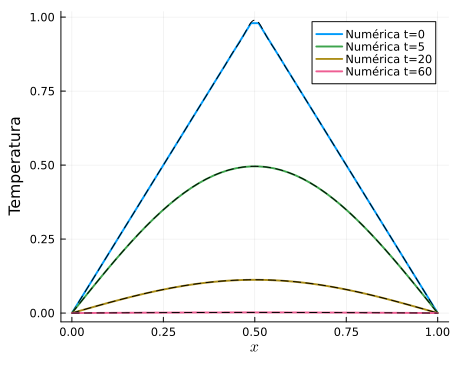

In [14]:
using Plots, LaTeXStrings, DifferentialEquations
N = 50
xs = range(0, 1, length = N)
dx = step(xs)
u0f(x) = x <= 0.5 ? 2x : 2(1 - x)
u0 = u0f.(xs)

function calor!(du, u, p, t)
    α, dx = p
    du[1] = 0.0; du[end] = 0.0            # extremos fijos a 0 °C
    for i in 2:length(u)-1
        du[i] = α * (u[i-1] - 2u[i] + u[i+1]) / dx^2
    end
end
prob = ODEProblem(calor!, u0, (0.0, 60.0), (0.01, dx))
sol = solve(prob, saveat = [0, 1, 5, 20, 60])

# Solución en serie para comparar:
bnf(k) = 8 * sin(k*π/2) / (k^2 * π^2)
userie(x, t) = sum(bnf(k) * sin(k*π*x) * exp(-0.01*(k*π)^2*t) for k in 1:2:40)

plt = plot(xlab = L"x", ylab = "Temperatura")
for (i, τ) in enumerate([0, 5, 20, 60])
    j = findfirst(==(τ), sol.t)
    plot!(plt, xs, sol.u[j], lw = 2, label = "Numérica t=$τ")
    plot!(plt, x -> userie(x, τ), 0, 1, ls = :dash, color = :black, label = "")
end
plt

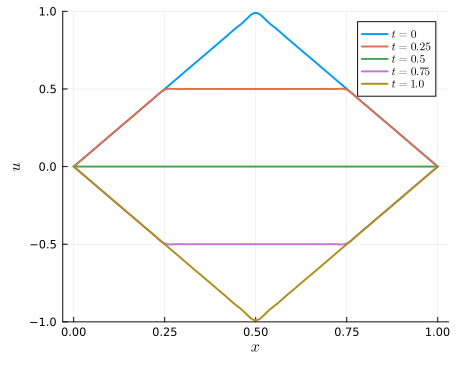

In [15]:
using Plots, LaTeXStrings
bnf(k) = 8 * sin(k*π/2) / (k^2 * π^2)
ucuerda(x, t; N = 40) = sum(bnf(k)*sin(k*π*x)*cos(k*π*t) for k in 1:2:N)
plt = plot(xlab = L"x", ylab = L"u", ylims = (-1, 1))
for τ in (0, 0.25, 0.5, 0.75, 1.0)
    plot!(plt, x -> ucuerda(x, τ), 0, 1, lw = 2, label = L"t=%$τ")
end
plt

In [16]:
maximum(abs(ucuerda(x, 0.3) - ucuerda(x, 0.3 + 2)) for x in 0:0.01:1)

9.992007221626409e-16

In [17]:
using SymPyPythonCall
@syms x y
u = 100 * sinh(PI*y) / sinh(PI) * sin(PI*x)
simplify(diff(u, x, 2) + diff(u, y, 2))

0

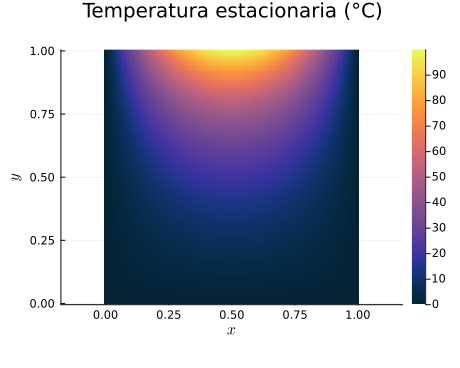

In [18]:
using Plots, LaTeXStrings
usol(x, y) = 100 * sinh(π*y) / sinh(π) * sin(π*x)
xs = ys = range(0, 1, length = 100)
heatmap(xs, ys, (x, y) -> usol(x, y), xlab = L"x", ylab = L"y",
        title = "Temperatura estacionaria (°C)", color = :thermal, aspect_ratio = :equal)

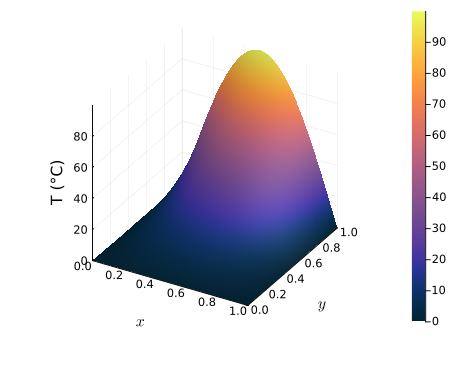

In [19]:
surface(xs, ys, (x, y) -> usol(x, y), xlab = L"x", ylab = L"y",
        zlab = "T (°C)", color = :thermal)

In [20]:
using SymPyPythonCall, SpecialFunctions
Φ(x) = (1 + erf(x / sqrt(2))) / 2   # erf disponible vía SymPy
function black_scholes_call(S, K, r, σ, T)
    d1 = (log(S/K) + (r + σ^2/2)*T) / (σ*sqrt(T))
    d2 = d1 - σ*sqrt(T)
    S*Φ(d1) - K*exp(-r*T)*Φ(d2)
end
precio = black_scholes_call(100.0, 100.0, 0.05, 0.20, 1.0)

10.450583572185565

In [21]:
Smax = 300.0; M = 300
Ss = range(0, Smax, length = M+1)
dS = step(Ss)
r, σ, K, T = 0.05, 0.20, 100.0, 1.0
payoff(S) = max(S - K, 0.0)

# τ = T - t : integramos hacia adelante en τ desde el payoff.
function bs!(dV, V, p, τ)
    r, σ, dS, Ss = p
    dV[1] = 0.0
    for i in 2:length(V)-1
        S = Ss[i]
        Vss = (V[i-1] - 2V[i] + V[i+1]) / dS^2
        Vs  = (V[i+1] - V[i-1]) / (2dS)
        dV[i] = 0.5*σ^2*S^2*Vss + r*S*Vs - r*V[i]
    end
    # Contorno superior: V ≈ S - K e^{-rτ}
    dV[end] = r * dS   # mantiene la pendiente ~1
end
V0 = payoff.(Ss)
sol = solve(ODEProblem(bs!, V0, (0.0, T), (r, σ, dS, Ss)), saveat = T)
# Interpolación lineal en S = 100:
i = searchsortedlast(Ss, 100.0)
Vnum = sol.u[end][i] + (sol.u[end][i+1] - sol.u[end][i]) * (100 - Ss[i]) / dS
(formula = precio, numerico = Vnum)

(formula = 10.450583572185565, numerico = 10.447887437387626)